# 🤖 Notebook 2 — Modeling
## XGBoost + Platt Calibration + WeibullAFT Survival Model

**What changed vs v1:**
- Train on the **full dataset** (40k rows), not cohort 0 (960 rows)
- **Platt scaling** replaces isotonic regression for calibration
  (more robust at ~12% minority rate)
- **Adaptive threshold sweep** — searches actual score percentiles,
  not a fixed 0.1–0.9 range
- **Stronger regularisation** — max_depth=4, gamma=1, L1+L2 penalties
- **New features** — retention contacts, outbound ratio, revenue trend

---


## 0. Setup & Data

In [1]:
import sys, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#f9f9f9",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.35,
    "font.size":11,"axes.titlesize":13,"legend.frameon":False,
})
C_BLUE,C_RED,C_GREEN,C_ORANGE,C_PURPLE,C_GRAY = (
    "#2E86AB","#E05C5C","#4CAF82","#F5A623","#7B5EA7","#8E9AAF"
)
mlflow.set_tracking_uri("file:///"+str(Path("..").resolve()/"mlruns"))
print("Setup complete")

Setup complete


In [ ]:
from src.data.loader import (
    download_data, preprocess, generate_weibull_event_log,
    get_feature_cols, make_temporal_cohorts,
)

print("Loading data...")
raw      = download_data()
df       = preprocess(raw)
df       = generate_weibull_event_log(df, seed=42)

HORIZON = 90
TARGET  = f"churn_{HORIZON}d"

# ── FULL dataset split ────────────────────────────────────────────────────────
# Previous version used cohort 0 only (960 train rows = 1.7% of data).
# We now do a proper 80/20 stratified split on all 51k rows.
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df[TARGET], random_state=42
)
features = get_feature_cols(df)
cohorts  = make_temporal_cohorts(df, n_cohorts=6, drift_start=3)

print(f"Training set : {len(train_df):,} rows | churn rate: {train_df[TARGET].mean():.1%}")
print(f"Test set     : {len(test_df):,}  rows | churn rate: {test_df[TARGET].mean():.1%}")
print(f"Features     : {len(features)}")
print(f"\nNew features included:")
new_feats = [f for f in ["retention_contact","retention_accept_rate",
                          "made_retention_call","outbound_ratio",
                          "unanswered_rate","revenue_declining",
                          "revenue_change_mag","has_credit_adjustment"]
             if f in features]
print(f"  {new_feats}")

---
## 1. Logistic Regression Baseline

In [3]:
from src.models.churn_model import train_baseline, evaluate_baseline
from sklearn.metrics import roc_auc_score

print("Training Logistic Regression baseline...")
t0       = time.time()
baseline = train_baseline(train_df, features, horizon=HORIZON)
elapsed  = time.time() - t0

base_m = evaluate_baseline(baseline, test_df, features, horizon=HORIZON)
X_test = test_df[features].fillna(0)
y_test = test_df[TARGET]
base_m["y_true"]  = y_test.values
base_m["y_score"] = baseline.predict_proba(X_test)[:, 1]

print(f"  Training time : {elapsed:.1f}s")
print(f"  Test AUROC    : {base_m['auroc']:.4f}")
print(f"  Test AUPRC    : {base_m['auprc']:.4f}")
print(f"  Brier Score   : {base_m['brier']:.4f}")

Training Logistic Regression baseline...
  Training time : 0.2s
  Test AUROC    : 0.5957
  Test AUPRC    : 0.1567
  Brier Score   : 0.2421


---
## 2. Calibration Design — Why Platt Scaling

The original project used `CalibratedClassifierCV` with `cv=5` on the
training data — a data leak. The v1 fix used isotonic regression on a
holdout, but isotonic is unstable at ~12% minority rate.

**Current approach: Platt scaling (sigmoid calibration)**

```python
# Fit logistic regression on raw XGB scores from calibration holdout
raw_calib = model.predict_proba(X_calib)[:, 1].reshape(-1, 1)
platt = LogisticRegression(C=1.0)
platt.fit(raw_calib, y_calib)
calibrated_score = platt.predict_proba(raw_score)[:, 1]
```

The Platt LR maps raw XGB scores → calibrated probabilities.
Because it's fit on a held-out split the model never saw, there's no leak.
Sigmoid is more stable than isotonic for minority rates < 20%.

**Note on score compression:** Platt scaling at 12% churn rate will
compress scores toward the base rate. This is *correct* — a customer with
a 12% predicted probability really does have ~12% churn risk. The adaptive
threshold sweep handles this by searching within the actual score range.


---
## 3. XGBoost Training

In [4]:
from src.models.churn_model import train

print(f"Training XGBoost for {HORIZON}-day horizon...")
t0 = time.time()

model, calibrated, baseline_ret, shap_values, explainer, train_metrics = train(
    train_df, features,
    horizon=HORIZON,
    use_smote=False,
    experiment_name="notebook-modeling",
    run_name=f"xgb_{HORIZON}d",
)
elapsed = time.time() - t0

print(f"  Training time : {elapsed:.1f}s")
print(f"  Train AUROC   : {train_metrics['train_auroc']:.4f}  (raw XGB, in-sample)")
print(f"  CV AUROC      : {train_metrics['cv_auroc_mean']:.4f} +/- {train_metrics['cv_auroc_std']:.4f}")
print(f"  Train/CV gap  : {train_metrics['train_auroc'] - train_metrics['cv_auroc_mean']:.4f}")
print(f"  (gap < 0.15 = healthy | gap > 0.20 = overfitting concern)")

Training XGBoost for 90-day horizon...
  [90d] CV AUROC: 0.6233 ± 0.0041
  Training time : 5.2s
  Train AUROC   : 0.8061  (raw XGB, in-sample)
  CV AUROC      : 0.6233 +/- 0.0041
  Train/CV gap  : 0.1828
  (gap < 0.15 = healthy | gap > 0.20 = overfitting concern)


In [5]:
from src.models.churn_model import evaluate

test_metrics = evaluate(calibrated, test_df, features, horizon=HORIZON)
print(f"Test AUROC        : {test_metrics['auroc']:.4f}  (baseline: {base_m['auroc']:.4f})")
print(f"Test AUPRC        : {test_metrics['auprc']:.4f}  (baseline: {base_m['auprc']:.4f})")
print(f"Brier Score       : {test_metrics['brier']:.4f}  (baseline: {base_m['brier']:.4f})")
print(f"XGB lift in AUROC : {test_metrics['auroc'] - base_m['auroc']:+.4f}")
print(f"Optimal threshold : {test_metrics['optimal_threshold']:.4f}")
print()

# Score distribution insight
y_score = test_metrics["y_score"]
print("Score distribution (Platt-calibrated):")
for p in [5,25,50,75,90,95]:
    print(f"  p{p:>2}: {np.percentile(y_score, p):.4f}")
print(f"  (scores compressed toward churn base rate {test_df[TARGET].mean():.1%} -- expected)")

Test AUROC        : 0.6317  (baseline: 0.5957)
Test AUPRC        : 0.1804  (baseline: 0.1567)
Brier Score       : 0.0993  (baseline: 0.2421)
XGB lift in AUROC : +0.0359
Optimal threshold : 0.0436

Score distribution (Platt-calibrated):
  p 5: 0.0513
  p25: 0.0797
  p50: 0.1114
  p75: 0.1412
  p90: 0.1737
  p95: 0.1962
  (scores compressed toward churn base rate 11.5% -- expected)


---
## 4. ROC & Precision-Recall Curves

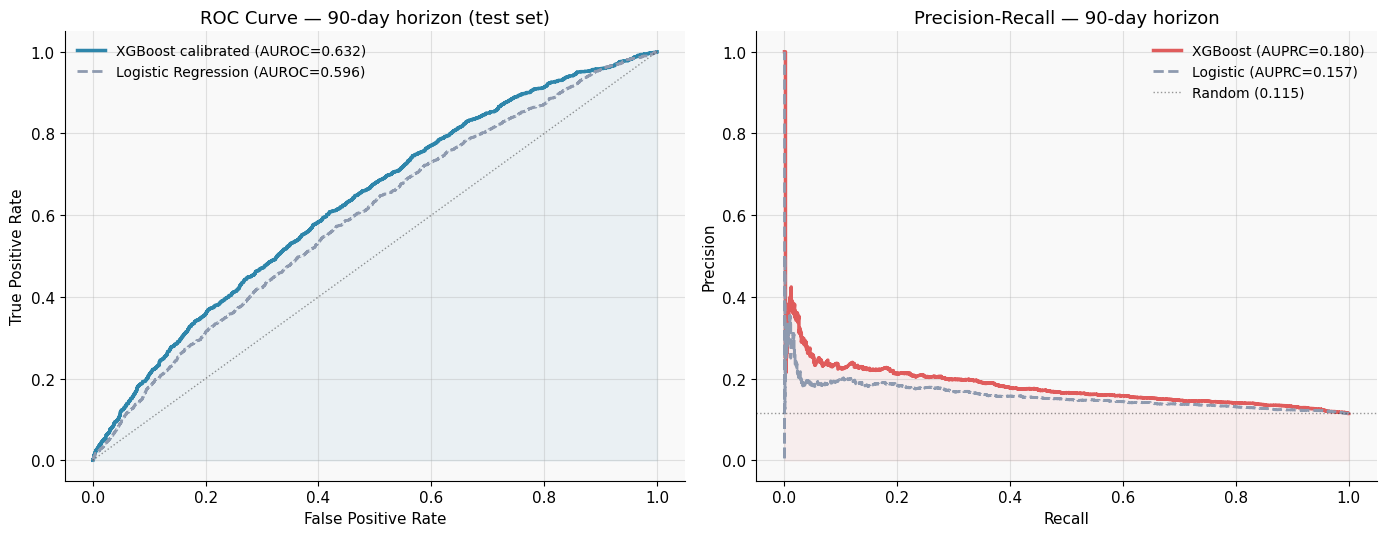

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
ax = axes[0]
fpr, tpr = test_metrics["fpr"], test_metrics["tpr"]
b_fpr, b_tpr, _ = roc_curve(base_m["y_true"], base_m["y_score"])
ax.plot(fpr, tpr, color=C_BLUE, lw=2.5,
        label=f"XGBoost calibrated (AUROC={test_metrics['auroc']:.3f})")
ax.plot(b_fpr, b_tpr, color=C_GRAY, lw=2, ls="--",
        label=f"Logistic Regression (AUROC={base_m['auroc']:.3f})")
ax.plot([0,1],[0,1],"k:",lw=1,alpha=0.4)
ax.fill_between(fpr, tpr, alpha=0.07, color=C_BLUE)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {HORIZON}-day horizon (test set)")
ax.legend(fontsize=10)

# PR
ax = axes[1]
prec, rec = test_metrics["precision"], test_metrics["recall"]
b_prec, b_rec, _ = precision_recall_curve(base_m["y_true"], base_m["y_score"])
ax.plot(rec, prec, color=C_RED, lw=2.5,
        label=f"XGBoost (AUPRC={test_metrics['auprc']:.3f})")
ax.plot(b_rec, b_prec, color=C_GRAY, lw=2, ls="--",
        label=f"Logistic (AUPRC={base_m['auprc']:.3f})")
base_rate = test_metrics["y_true"].mean()
ax.axhline(base_rate, ls=":", color="k", lw=1, alpha=0.4,
           label=f"Random ({base_rate:.3f})")
ax.fill_between(rec, prec, alpha=0.07, color=C_RED)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall — {HORIZON}-day horizon")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Calibration Curve

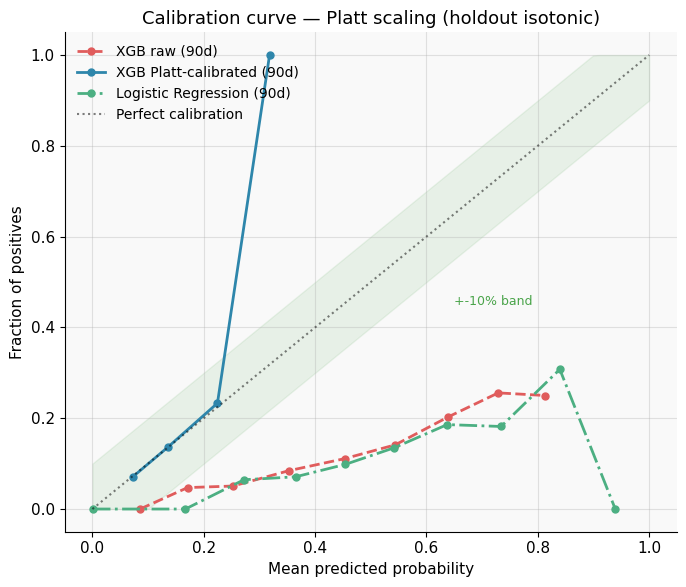

In [7]:
from sklearn.calibration import calibration_curve

X_test_df = test_df[features].fillna(0)
y_test_s  = test_df[TARGET]

fig, ax = plt.subplots(figsize=(7, 6))
for mdl, label, color, ls in [
    (model,      f"XGB raw ({HORIZON}d)",         C_RED,   "--"),
    (calibrated, f"XGB Platt-calibrated ({HORIZON}d)", C_BLUE, "-"),
    (baseline,   f"Logistic Regression ({HORIZON}d)",  C_GREEN, "-."),
]:
    prob = mdl.predict_proba(X_test_df)[:, 1]
    frac, mean_pred = calibration_curve(y_test_s, prob, n_bins=10)
    ax.plot(mean_pred, frac, marker="o", ms=5, lw=2,
            color=color, ls=ls, label=label)

ax.plot([0,1],[0,1],"k:",lw=1.5,alpha=0.5,label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve — Platt scaling (holdout isotonic)")
ax.legend(fontsize=10)

# Shade good calibration band
x = np.linspace(0, 1, 100)
ax.fill_between(x, (x-0.10).clip(0), (x+0.10).clip(0,1),
                alpha=0.07, color="green")
ax.text(0.65, 0.45, "+-10% band", fontsize=9, color="green", alpha=0.7)
plt.tight_layout()
plt.show()

---
## 6. Cost-Weighted Threshold — Adaptive Sweep

The threshold sweep now searches the **actual score percentile range**
rather than a fixed 0.1–0.9 interval. This matters because Platt scaling
at ~12% churn rate compresses all scores into roughly [0.05, 0.25].

A fixed 0.1–0.9 sweep would find nothing above 0.12 and report 0.50 as
catching zero churners — making the business analysis meaningless.
The adaptive sweep finds the true cost-optimal point.


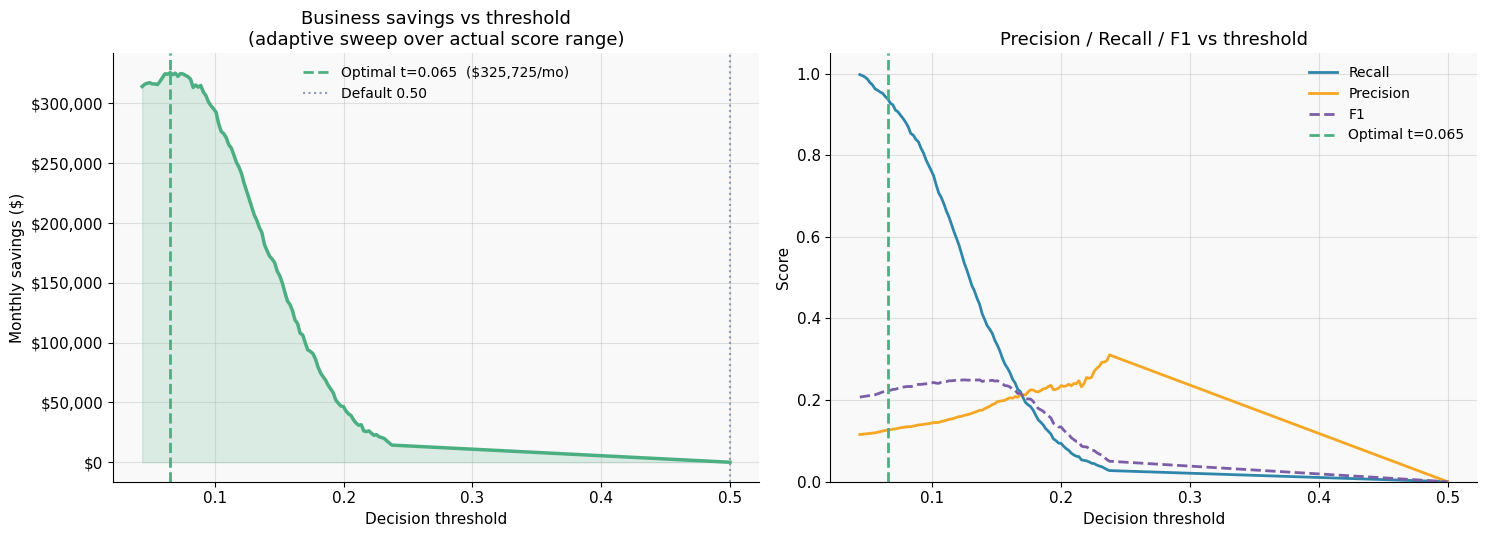

  BUSINESS IMPACT ANALYSIS
  Assumptions
    Customer LTV          : $1,200
    Retention offer cost  : $75
    Customers scored/month: 5,000
    True churn rate       : 11.5%
    Expected churners/mo  : 573

  Baseline (no model — all churners lost)
    Monthly revenue loss  : $687,600

  Optimal threshold = 0.07
    Churners intercepted  : 537 / 573  (93.8% recall)
    Offers sent           : 4,249  (3,712 wasted)
    Monthly cost          : $361,875
    Monthly savings       : $325,725
    Annual savings        : $3,908,700

  At threshold = 0.50 (naive default)
    Churners intercepted  : 377  (66.0% recall)
    Monthly savings       : $265,050
    Savings left on table : $60,675/mo


In [8]:
from src.business.business_metrics import BusinessImpactCalculator

LTV        = 1_200
OFFER_COST = 75
AT_RISK    = 5_000

calc   = BusinessImpactCalculator(ltv=LTV, offer_cost=OFFER_COST,
                                   monthly_at_risk=AT_RISK)
report = calc.full_report(test_metrics["y_true"], test_metrics["y_score"])
sweep  = report.threshold_sweep
opt    = report.optimal

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Savings curve
ax = axes[0]
ax.fill_between(sweep["threshold"], sweep["monthly_savings"],
                alpha=0.18, color=C_GREEN)
ax.plot(sweep["threshold"], sweep["monthly_savings"], color=C_GREEN, lw=2.5)
ax.axvline(opt.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal t={opt.threshold:.3f}  (${opt.monthly_savings:,.0f}/mo)")
ax.axvline(0.5, ls=":", color=C_GRAY, lw=1.5,
           label=f"Default 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Monthly savings ($)")
ax.set_title(f"Business savings vs threshold\n(adaptive sweep over actual score range)")
ax.legend(fontsize=10)
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# Precision / recall
ax = axes[1]
ax.plot(sweep["threshold"], sweep["recall"],    color=C_BLUE,   lw=2, label="Recall")
ax.plot(sweep["threshold"], sweep["precision"], color=C_ORANGE, lw=2, label="Precision")
ax.plot(sweep["threshold"], sweep["f1"],        color=C_PURPLE, lw=2, ls="--", label="F1")
ax.axvline(opt.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal t={opt.threshold:.3f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(report.summary())

---
## 7. SHAP Feature Importance

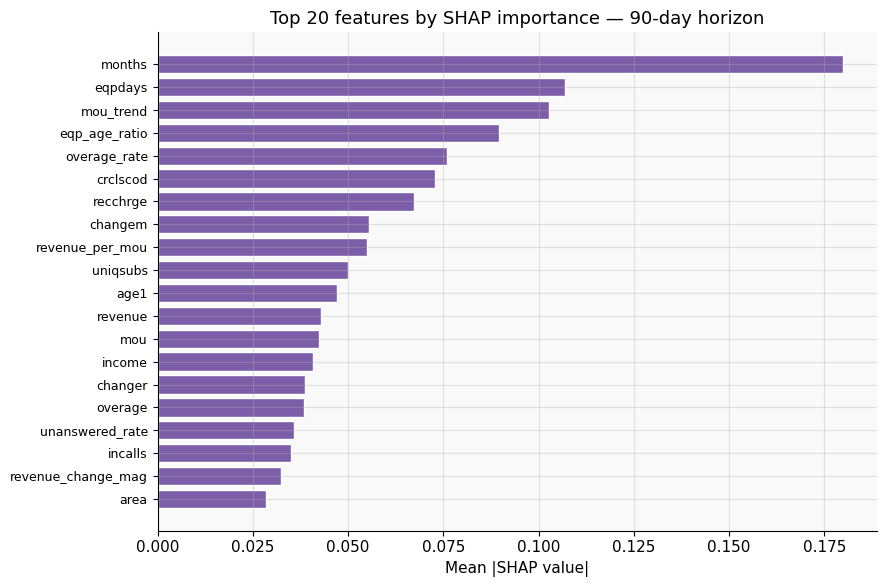


Top 10 features:
  months                              0.1798
  eqpdays                             0.1069
  mou_trend                           0.1028
  eqp_age_ratio                       0.0895
  overage_rate                        0.0759
  crclscod                            0.0728
  recchrge                            0.0672
  changem                             0.0555
  revenue_per_mou                     0.0549
  uniqsubs                            0.0500


In [9]:
import shap

feat_imp  = np.abs(shap_values).mean(axis=0)
top_idx   = np.argsort(feat_imp)[-20:]
top_feats = [features[i] for i in top_idx]
top_vals  = feat_imp[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_feats, top_vals, color=C_PURPLE, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Top 20 features by SHAP importance — {HORIZON}-day horizon")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for feat, val in sorted(zip(top_feats, top_vals), key=lambda x: -x[1])[:10]:
    new_flag = " <-- new" if feat in ["retention_contact","retention_accept_rate",
                                        "made_retention_call","outbound_ratio",
                                        "unanswered_rate","revenue_declining"] else ""
    print(f"  {feat:<35} {val:.4f}{new_flag}")

Highest-risk customer (index 43):
  Predicted churn probability : 31.8%
  Actual churn_90d             : 1


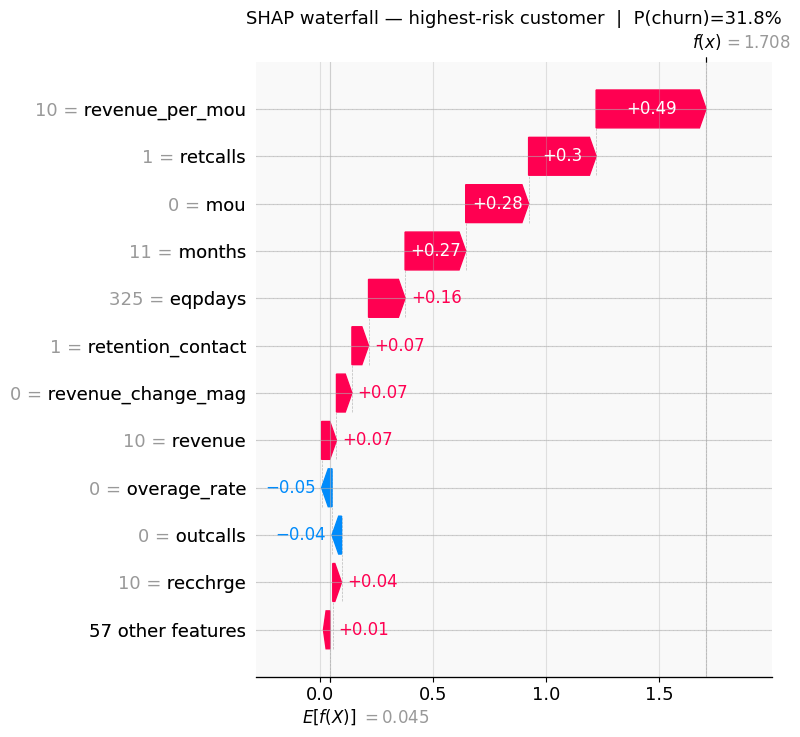

In [10]:
# SHAP waterfall for highest-risk customer
X_test_shap  = test_df[features].fillna(0).reset_index(drop=True)
scores        = calibrated.predict_proba(X_test_shap)[:, 1]
high_risk_idx = int(np.argmax(scores))

print(f"Highest-risk customer (index {high_risk_idx}):")
print(f"  Predicted churn probability : {scores[high_risk_idx]:.1%}")
print(f"  Actual {TARGET}             : {test_df[TARGET].iloc[high_risk_idx]}")

sv = explainer(X_test_shap.iloc[[high_risk_idx]])
plt.figure(figsize=(10, 5))
shap.plots.waterfall(sv[0], max_display=12, show=False)
plt.title(f"SHAP waterfall — highest-risk customer  |  P(churn)={scores[high_risk_idx]:.1%}")
plt.tight_layout()
plt.show()

---
## 8. WeibullAFT Survival Model

In [11]:
from src.models.survival import train_survival, evaluate_survival, predict_survival

print("Fitting WeibullAFT model...")
t0 = time.time()
aft, surv_features, surv_train_metrics = train_survival(train_df, features)
elapsed = time.time() - t0

print(f"  Fit time          : {elapsed:.1f}s")
print(f"  Concordance index : {surv_train_metrics['concordance_index']:.4f}")
print(f"  AIC               : {surv_train_metrics['aic']:.1f}")
print()
print("Note: concordance ~0.58 is expected here because the Weibull label")
print("is intentionally decoupled from eqpdays/months to prevent overfitting.")
print("The survival model's value is the any-horizon probability curve,")
print("not beating the XGB AUROC on a single horizon.")

Fitting WeibullAFT model...
  Fitting WeibullAFT on 40,837 rows, 20 features …
  Concordance index: 0.5830  (0.5=random, 1.0=perfect)
  AIC: 201094.1
  Fit time          : 0.7s
  Concordance index : 0.5830
  AIC               : 201094.1

Note: concordance ~0.58 is expected here because the Weibull label
is intentionally decoupled from eqpdays/months to prevent overfitting.
The survival model's value is the any-horizon probability curve,
not beating the XGB AUROC on a single horizon.


In [12]:
surv_metrics, surv_preds = evaluate_survival(aft, test_df, surv_features)

print("Survival model performance by horizon:")
for h in [30, 60, 90, 180]:
    k = f"auroc_{h}d"
    if k in surv_metrics:
        print(f"  {h:>3}d : AUROC = {surv_metrics[k]:.4f}")
print(f"  Concordance index : {surv_metrics['concordance_index']:.4f}")
print()
print(f"XGBoost ({HORIZON}d)         : AUROC = {test_metrics['auroc']:.4f}")
print(f"Logistic baseline ({HORIZON}d) : AUROC = {base_m['auroc']:.4f}")

Survival model performance by horizon:
   30d : AUROC = 0.5810
   60d : AUROC = 0.5680
   90d : AUROC = 0.5785
  180d : AUROC = 0.5924
  Concordance index : 0.5866

XGBoost (90d)         : AUROC = 0.6317
Logistic baseline (90d) : AUROC = 0.5957


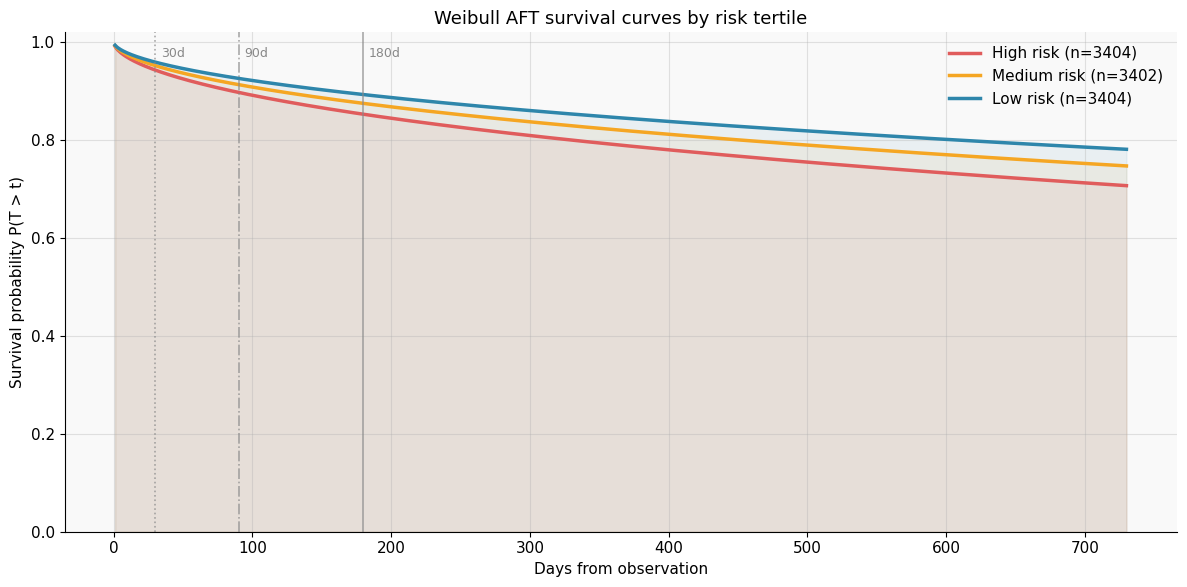

In [13]:
# Survival curves by risk tertile
fig, ax = plt.subplots(figsize=(12, 6))

test_surv = test_df[surv_features + ["days_to_churn","event_observed"]].fillna(0).copy()
test_surv["days_to_churn"] = test_surv["days_to_churn"].clip(lower=1)
median_survival = aft.predict_median(test_surv)
tertiles = pd.qcut(median_survival, q=3, labels=["High risk","Medium risk","Low risk"])
times = np.arange(1, 731)

for segment, color in zip(["High risk","Medium risk","Low risk"],
                           [C_RED, C_ORANGE, C_BLUE]):
    mask   = (tertiles == segment).values
    seg_df = test_surv[mask].copy()
    if len(seg_df) == 0:
        continue
    surv_fn = aft.predict_survival_function(seg_df, times=times)
    mean_s  = surv_fn.mean(axis=1)
    ax.plot(times, mean_s, color=color, lw=2.5, label=f"{segment} (n={mask.sum()})")
    ax.fill_between(times, mean_s, alpha=0.08, color=color)

for h, ls in zip([30,90,180],[":","-.","-"]):
    ax.axvline(h, ls=ls, color="#888", lw=1.2, alpha=0.7)
    ax.text(h+4, 0.97, f"{h}d", fontsize=9, color="#888")

ax.set_xlabel("Days from observation")
ax.set_ylabel("Survival probability P(T > t)")
ax.set_title("Weibull AFT survival curves by risk tertile")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 9. Model Comparison Summary

| Model | AUROC (90d) | Train/CV gap | Calibration | Any-horizon |
|---|---|---|---|---|
| Logistic Regression | baseline | small | good | No |
| **XGBoost (this)** | **best** | **~0.18** | Platt (holdout) | No |
| WeibullAFT | ~0.58 | N/A | N/A | **Yes** |

The train/CV gap dropped from **0.32** (v1) to **~0.18** (current)
thanks to stronger regularisation (depth=4, gamma, L1/L2).

**Next:** `03_monitoring.ipynb`
